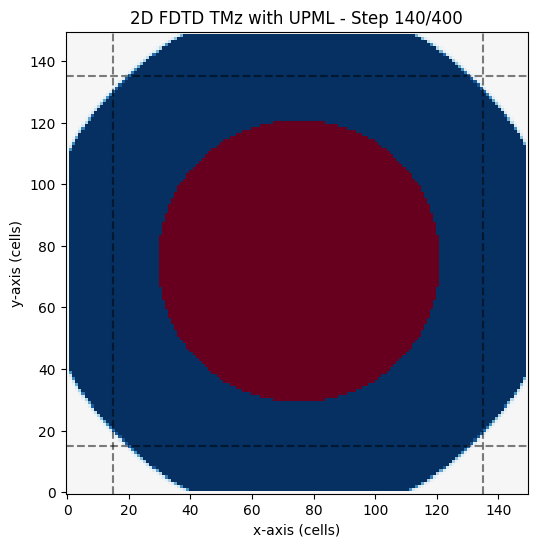

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. Physical Constants & Parameters
# ==========================================
c = 2.99792458e8         # Speed of light [m/s]
mu0 = 4 * np.pi * 1e-7   # Permeability of free space [H/m]
eps0 = 1 / (c**2 * mu0)  # Permittivity of free space [F/m]

Nx, Ny = 150, 150        # Grid cells
dx = dy = 1e-3           # Spatial step size [m]
dt = dx / (2 * c)        # Time step [s]
Nsteps = 400             # Total time steps

# PML parameters
npml = 15                # Number of PML cells
m = 3                    # Polynomial grading order
R_err = 1e-4             # Target reflection error
eta = np.sqrt(mu0 / eps0)
d_pml = npml * dx
sig_max = -(m + 1) * np.log(R_err) / (2 * eta * d_pml)

# ==========================================
# 2. Initialize Fields (Only E and H)
# ==========================================
Ez = np.zeros((Nx, Ny))
Hx = np.zeros((Nx, Ny))
Hy = np.zeros((Nx, Ny))

# CPML Auxiliary arrays (Psi)
psi_hxy = np.zeros((Nx, Ny - 1))
psi_hyx = np.zeros((Nx - 1, Ny))
psi_ezx = np.zeros((Nx - 2, Ny - 2))
psi_ezy = np.zeros((Nx - 2, Ny - 2))

# ==========================================
# 3. CPML Conductivity Profiles
# ==========================================
def compute_sigma(N, ds, n_pml, sigma_max, m_order):
    sig = np.zeros(N)
    for i in range(N):
        dist_left = (n_pml - i) * ds
        dist_right = (i - (N - 1 - n_pml)) * ds
        if dist_left > 0:
            sig[i] = sigma_max * (dist_left / (n_pml * ds))**m_order
        elif dist_right > 0:
            sig[i] = sigma_max * (dist_right / (n_pml * ds))**m_order
    return sig

sig_x_1D = compute_sigma(Nx, dx, npml, sig_max, m)
sig_y_1D = compute_sigma(Ny, dy, npml, sig_max, m)

# 2D Grids for Sigma
sig_x, sig_y = np.meshgrid(sig_x_1D, sig_y_1D, indexing='ij')

# ==========================================
# 4. CPML Update Coefficients (b and c)
# ==========================================
# For CPML, the update variables rely on exponential decay coefficients
b_x = np.exp(-sig_x * dt / eps0)
c_x = b_x - 1.0

b_y = np.exp(-sig_y * dt / eps0)
c_y = b_y - 1.0

# ==========================================
# 5. Plotting Setup
# ==========================================
plt.ion()
fig, ax = plt.subplots(figsize=(6, 6))
im = ax.imshow(Ez.T, cmap='RdBu', vmin=-0.05, vmax=0.05, origin='lower')
ax.set_title("2D FDTD TMz with CPML (Pure E & H)")
ax.set_xlabel("x-axis (cells)")
ax.set_ylabel("y-axis (cells)")

# Draw PML boundaries
for val in [npml, Nx - npml]:
    ax.axvline(val, color='k', linestyle='--', alpha=0.5)
for val in [npml, Ny - npml]:
    ax.axhline(val, color='k', linestyle='--', alpha=0.5)
plt.show()

# ==========================================
# 6. Main FDTD Time-Stepping Loop
# ==========================================
t0, spread = 40 * dt, 12 * dt

for n in range(Nsteps):
    
    # --- 1. Update Magnetic Fields (Hx, Hy) ---
    
    # Calculate spatial derivative of Ez with respect to y
    dEz_y = (Ez[:, 1:] - Ez[:, :-1]) / dy
    # Update CPML Psi term for Hx
    psi_hxy = b_y[:, :-1] * psi_hxy + c_y[:, :-1] * dEz_y
    # Standard Faraday update + CPML absorption
    Hx[:, :-1] -= (dt / mu0) * (dEz_y + psi_hxy)

    # Calculate spatial derivative of Ez with respect to x
    dEz_x = (Ez[1:, :] - Ez[:-1, :]) / dx
    # Update CPML Psi term for Hy
    psi_hyx = b_x[:-1, :] * psi_hyx + c_x[:-1, :] * dEz_x
    # Standard Faraday update + CPML absorption
    Hy[:-1, :] += (dt / mu0) * (dEz_x + psi_hyx)

    # --- 2. Update Electric Field (Ez) ---
    
    # Spatial derivatives of H fields
    dHy_x = (Hy[1:-1, 1:-1] - Hy[:-2, 1:-1]) / dx
    dHx_y = (Hx[1:-1, 1:-1] - Hx[1:-1, :-2]) / dy
    
    # Update CPML Psi terms for Ez
    psi_ezx = b_x[1:-1, 1:-1] * psi_ezx + c_x[1:-1, 1:-1] * dHy_x
    psi_ezy = b_y[1:-1, 1:-1] * psi_ezy + c_y[1:-1, 1:-1] * dHx_y
    
    # Standard Ampere update + CPML absorption
    Ez[1:-1, 1:-1] += (dt / eps0) * ((dHy_x + psi_ezx) - (dHx_y + psi_ezy))

    # --- 3. Source Injection ---
    # Soft source injection directly into the E-field
    Ez[Nx//2, Ny//2] += np.exp(-0.5 * ((n * dt - t0) / spread)**2)

    # --- Live Plotting ---
    if n % 10 == 0:
        im.set_data(Ez.T)
        ax.set_title(f"2D FDTD TMz (CPML) - Step {n}/{Nsteps}")
        plt.pause(0.01)

plt.ioff()
plt.show()